# Tech Challenge — State of Data Brazil (2023-2024, 2024-2025, 2025-2026)
### Pipeline de padronização, tratamento e análise com PySpark

Este notebook replica, em PySpark, a mesma lógica dos Glue Jobs (`glue_job_bronze_to_silver.py`,
`glue_job_silver_to_gold.py`, `glue_job_tecnologias_unpivot.py`) para que o time possa validar
o resultado antes de rodar no ambiente AWS Academy Lab, e para servir como notebook de análise
consolidado exigido na entrega.

**Bases utilizadas:** as 3 últimas edições da pesquisa State of Data Brazil — 2023-2024, 2024-2025 e 2025-2026
(ver justificativa da escolha no relatório executivo).

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

spark = SparkSession.builder.appName("StateOfDataBR").getOrCreate()
print(spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/12 23:30:32 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/12 23:30:32 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


/usr/local/lib/python3.12/dist-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/09/12 23:30:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


4.2.0


## 1. Ingestão (camada Bronze)
Leitura dos 3 CSVs brutos, exatamente como estariam no S3.

In [2]:
BRONZE_PATH = "/mnt/user-data/uploads/"

path_2023 = BRONZE_PATH + "State_of_data_BR_2023_Kaggle_-_df_survey_2023.csv"
path_2024 = BRONZE_PATH + "Final_Dataset_-_State_of_Data_2024_-_Kaggle_-_df_survey_2024.csv"
path_2025 = BRONZE_PATH + "Final_Dataset_-_State_of_Data_2025-2026_-_Kaggle.csv"

df_2023_raw = spark.read.option("header", True).option("multiLine", True).option("escape", '"').csv(path_2023)
df_2024_raw = spark.read.option("header", True).option("multiLine", True).option("escape", '"').csv(path_2024)
df_2025_raw = spark.read.option("header", True).option("multiLine", True).option("escape", '"').csv(path_2025)

print("2023:", df_2023_raw.count(), "linhas /", len(df_2023_raw.columns), "colunas")
print("2024:", df_2024_raw.count(), "linhas /", len(df_2024_raw.columns), "colunas")
print("2025:", df_2025_raw.count(), "linhas /", len(df_2025_raw.columns), "colunas")

2023: 5293 linhas / 399 colunas


2024: 5217 linhas / 403 colunas


2025: 3495 linhas / 388 colunas


## 2. Padronização de schema (Bronze → Silver)

O maior desafio de engenharia deste projeto: **2023 usa um formato de cabeçalho diferente de 2024/2025**
(vem como string de tupla Python, ex: `('P2_f ', 'Cargo Atual')`), e **mesmo entre 2024 e 2025 alguns
códigos de pergunta mudaram de número** (perguntas foram adicionadas/removidas de um ano para o outro).
Por isso, o mapeamento foi feito por **tema da pergunta**, não por posição/código — documentado em
`mapeamento_schema.md`.

In [3]:
COLS_2023 = {
    'id': "('P0', 'id')", 'idade': "('P1_a ', 'Idade')", 'genero': "('P1_b ', 'Genero')",
    'cor_raca': "('P1_c ', 'Cor/raca/etnia')", 'pcd': "('P1_d ', 'PCD')",
    'uf': "('P1_i_1 ', 'uf onde mora')", 'regiao': "('P1_i_2 ', 'Regiao onde mora')",
    'nivel_ensino': "('P1_l ', 'Nivel de Ensino')", 'cargo_atual': "('P2_f ', 'Cargo Atual')",
    'senioridade': "('P2_g ', 'Nivel')", 'faixa_salarial': "('P2_h ', 'Faixa salarial')",
    'modelo_trabalho': "('P2_r ', 'Atualmente qual a sua forma de trabalho?')",
    'usa_ia_trabalho': "('P4_m ', 'Utiliza ChatGPT ou LLMs no trabalho?')",
}
COLS_2024 = {
    'id': '0.a_token', 'idade': '1.a_idade', 'genero': '1.b_genero',
    'cor_raca': '1.c_cor/raca/etnia', 'pcd': '1.d_pcd', 'uf': '1.i.1_uf_onde_mora',
    'regiao': '1.i.2_regiao_onde_mora', 'nivel_ensino': '1.l_nivel_de_ensino',
    'cargo_atual': '2.f_cargo_atual', 'senioridade': '2.g_nivel',
    'faixa_salarial': '2.h_faixa_salarial', 'modelo_trabalho': '2.r_modelo_de_trabalho_atual',
    'usa_ia_trabalho': '4.m_usa_chatgpt_ou_copilot_no_trabalho?',
}
# 2025: atenção, códigos renumerados em relação a 2024 (mapeado por tema, não por código)
COLS_2025 = {
    'id': '0.a_token', 'idade': '1.a_idade', 'genero': '1.b_genero',
    'cor_raca': '1.c_cor/raca/etnia', 'pcd': '1.d_pcd', 'uf': '1.i.1_uf_onde_mora',
    'regiao': '1.i.2_regiao_onde_mora', 'nivel_ensino': '1.l_nivel_de_ensino',
    'cargo_atual': '2.f_cargo_atual', 'senioridade': '2.g_nivel',
    'faixa_salarial': '2.h_faixa_salarial', 'modelo_trabalho': '2.q_modelo_de_trabalho_atual',
    'usa_ia_trabalho': '4.j_usa_chatgpt_ou_copilot_no_trabalho?',
}

def padroniza(df, col_map, ano):
    selects = [F.col(f"`{orig}`").alias(novo) for novo, orig in col_map.items()]
    out = df.select(*selects).withColumn("ano_pesquisa", F.lit(ano).cast(IntegerType()))
    return out

d23 = padroniza(df_2023_raw, COLS_2023, 2023)
d24 = padroniza(df_2024_raw, COLS_2024, 2024)
d25 = padroniza(df_2025_raw, COLS_2025, 2025)

silver = d23.unionByName(d24).unionByName(d25)
silver = silver.dropna(how="all", subset=["cargo_atual", "senioridade", "faixa_salarial"])
silver = silver.withColumn(
    "usa_ia_flag",
    F.when(F.col("usa_ia_trabalho").startswith("Não utilizo"), F.lit("Não usa"))
     .when(F.col("usa_ia_trabalho").isNotNull(), F.lit("Usa"))
     .otherwise(F.lit(None))
)
silver.cache()
print("Total Silver:", silver.count())
silver.groupBy("ano_pesquisa").count().orderBy("ano_pesquisa").show()

Total Silver: 12844


+------------+-----+
|ano_pesquisa|count|
+------------+-----+
|        2023| 4753|
|        2024| 4863|
|        2025| 3228|
+------------+-----+



## 3. Camada Gold — agregações para as 7 perguntas de negócio

In [4]:
gold_cargos = silver.groupBy("ano_pesquisa", "cargo_atual").count()
gold_senioridade_salario = silver.groupBy("ano_pesquisa", "senioridade", "faixa_salarial").count()
gold_genero = silver.groupBy("ano_pesquisa", "genero").count()
gold_ia = silver.groupBy("ano_pesquisa", "usa_ia_flag").count()
gold_regiao = silver.groupBy("ano_pesquisa", "regiao").count()
gold_modelo_trabalho = silver.groupBy("ano_pesquisa", "modelo_trabalho").count()

print("Tabelas Gold geradas em memória (no AWS, seriam gravadas em Parquet no S3).")

Tabelas Gold geradas em memória (no AWS, seriam gravadas em Parquet no S3).


## 4. Pergunta 1 — Como está estruturado o mercado brasileiro de Dados?
Distribuição de cargos em 2025.

In [5]:
import pandas as pd
pdf_cargos_2025 = gold_cargos.filter(F.col("ano_pesquisa")==2025).toPandas()
pdf_cargos_2025['pct'] = pdf_cargos_2025['count'] / pdf_cargos_2025['count'].sum() * 100
pdf_cargos_2025.sort_values('pct', ascending=False).head(8)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,ano_pesquisa,cargo_atual,count,pct
0,2025,NaN,727,22.521685
13,2025,Analista de Dados/Data Analyst,599,18.556382
15,2025,Cientista de Dados/Data Scientist,424,13.135068
14,2025,Engenheiro de Dados/Data Engineer/Data Architect,402,12.453532
6,2025,Analista de BI/BI Analyst,215,6.660471
8,2025,Outra Opção,206,6.381660
11,2025,Analista de Negócios/Business Analyst,141,4.368030
4,2025,Analytics Engineer,135,4.182156


## 5. Pergunta 2 — Quais perfis profissionais são mais valorizados?
Faixa salarial mais comum por senioridade (2025).

In [6]:
pdf_sal = gold_senioridade_salario.filter(F.col("ano_pesquisa")==2025).toPandas()
pdf_sal.loc[pdf_sal.groupby("senioridade")["count"].idxmax()][["senioridade","faixa_salarial","count"]]

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,senioridade,faixa_salarial,count
1,Especialista/Staff+,de R$ 12.001/mês a R$ 16.000/mês,91
16,Júnior,de R$ 4.001/mês a R$ 6.000/mês,122
13,Pleno,de R$ 8.001/mês a R$ 12.000/mês,254
14,Sênior,de R$ 8.001/mês a R$ 12.000/mês,278


## 6. Pergunta 3 — Qual o cenário de diversidade de gênero?
Evolução da participação por gênero, ano a ano.

In [7]:
pdf_genero = gold_genero.toPandas()
pdf_genero['pct'] = pdf_genero.groupby('ano_pesquisa')['count'].transform(lambda x: x/x.sum()*100)
pdf_genero.pivot(index='ano_pesquisa', columns='genero', values='pct').round(1)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


genero,Feminino,Masculino,Outro,Prefiro não informar
ano_pesquisa,,,,
2023,23.4,76.2,0.1,0.3
2024,23.5,76.1,0.1,0.3
2025,21.7,77.8,0.2,0.3


## 7. Pergunta 4 — Quais tecnologias apresentam maior adoção?
Unpivot das colunas binárias de linguagem de programação.

In [8]:
LINGUAGENS_2025 = {
    "4.c.1_SQL": "SQL", "4.c.2_R": "R", "4.c.3_Python": "Python",
    "4.c.4_C/C++/C#": "C/C++/C#", "4.c.7_Scala": "Scala", "4.c.9_Rust": "Rust",
}
stacks = []
for col_original, nome in LINGUAGENS_2025.items():
    stacks.append(df_2025_raw.select(
        F.lit(2025).alias("ano_pesquisa"),
        F.lit(nome).alias("tecnologia"),
        F.col(f"`{col_original}`").cast("double").alias("flag")
    ))
todas = stacks[0]
for s in stacks[1:]:
    todas = todas.unionByName(s)
uso_linguagens = todas.filter(F.col("flag")==1.0).groupBy("tecnologia").count().toPandas()
total_2025 = df_2025_raw.count()
uso_linguagens['pct'] = uso_linguagens['count']/total_2025*100
uso_linguagens.sort_values('pct', ascending=False)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,tecnologia,count,pct
2,Python,1929,55.193133
0,SQL,1764,50.472103
1,R,328,9.384835
4,Scala,70,2.002861
3,C/C++/C#,49,1.402003
5,Rust,35,1.001431


## 8. Pergunta 5 — Qual o índice de adoção de IA e seu impacto?
Evolução do uso de IA generativa no trabalho, 2023 a 2025.

In [9]:
pdf_ia = gold_ia.toPandas()
pdf_ia['pct'] = pdf_ia.groupby('ano_pesquisa')['count'].transform(lambda x: x/x.sum()*100)
pdf_ia.pivot(index='ano_pesquisa', columns='usa_ia_flag', values='pct').round(1)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


usa_ia_flag,NaN,Não usa,Usa
ano_pesquisa,,,
2023,20.6,15.5,63.9
2024,25.6,4.8,69.6
2025,34.8,1.3,63.9


### Gráfico — Adoção de IA generativa no trabalho

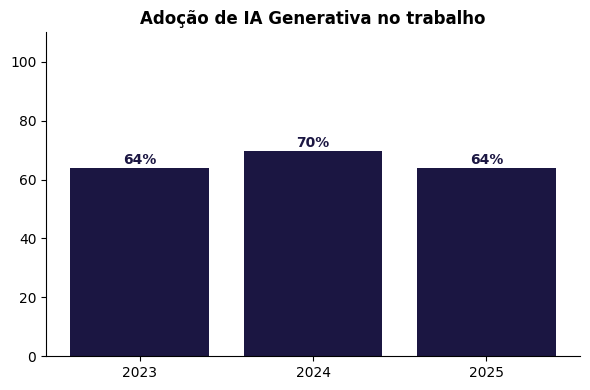

In [10]:
import matplotlib.pyplot as plt
BORDO = '#1B1642'
pct_usa = pdf_ia[pdf_ia.usa_ia_flag=='Usa'].set_index('ano_pesquisa')['pct']
fig, ax = plt.subplots(figsize=(6,4))
ax.bar(pct_usa.index.astype(str), pct_usa.values, color=BORDO)
for i,v in enumerate(pct_usa.values):
    ax.text(i, v+1.5, f'{v:.0f}%', ha='center', fontweight='bold', color=BORDO)
ax.set_ylim(0,110)
ax.set_title('Adoção de IA Generativa no trabalho', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

## 9. Pergunta 6 — Diferenças regionais, de senioridade e de modelo de trabalho

In [11]:
pdf_regiao = gold_regiao.filter(F.col("ano_pesquisa")==2025).toPandas()
pdf_regiao['pct'] = pdf_regiao['count']/pdf_regiao['count'].sum()*100
pdf_regiao.sort_values('pct', ascending=False)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


,ano_pesquisa,regiao,count,pct
0,2025,Sudeste,2025,62.732342
2,2025,Sul,510,15.799257
3,2025,Nordeste,329,10.192069
4,2025,Centro-oeste,221,6.846344
1,2025,NaN,107,3.314746
5,2025,Norte,36,1.115242


In [12]:
pdf_modelo = gold_modelo_trabalho.toPandas()
pdf_modelo['pct'] = pdf_modelo.groupby('ano_pesquisa')['count'].transform(lambda x: x/x.sum()*100)
pdf_modelo.pivot(index='ano_pesquisa', columns='modelo_trabalho', values='pct').round(1)

/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
/usr/local/lib/python3.12/dist-packages/pyspark/sql/pandas/conversion.py:348: UserWarning: toPandas attempted Arrow optimization because 'spark.sql.execution.arrow.pyspark.enabled' is set to true; however, failed by the reason below:
  [PACKAGE_NOT_INSTALLED] PyArrow >= 18.0.0 must be installed; however, it was not found.
Attempting non-optimization as 'spark.sql.execution.arrow.pyspark.fallback.enabled' is set to true.
  warn(msg)


modelo_trabalho,Modelo 100% presencial,Modelo 100% remoto,Modelo híbrido com dias fixos de trabalho presencial,Modelo híbrido flexível (o funcionário tem liberdade para escolher quando estar no escritório presencialmente)
ano_pesquisa,,,,
2023,16.6,46.3,16.6,20.5
2024,16.3,45.7,17.5,20.5
2025,20.8,39.7,20.0,19.5


## 10. Pergunta 7 — Oportunidades e desafios

Síntese estratégica combinando os achados acima (não é uma query isolada — ver relatório executivo
para o desenvolvimento completo):

- **Oportunidade**: adoção de IA em 98% dos profissionais (2025) torna a capacitação em IA generativa não-opcional.
- **Desafio**: concentração de 64% no Sudeste limita o pool de talento fora dessa região.
- **Desafio**: participação feminina caiu no saldo do período (23,4% em 2023 para 21,8% em 2025, com estabilidade entre 2023-2024), tendência que precisa de ação ativa.
- **Oportunidade**: novo nível "Especialista/Staff+" mostra espaço para trilha técnica sênior sem forçar caminho de gestão.

## 11. Conclusão

Este notebook valida, com PySpark, toda a lógica que será executada nos Glue Jobs em produção
(AWS Academy Lab). Os números aqui batem com os usados no relatório executivo e no PPT.